In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saraemad110/penggggg/penguins.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/saraemad110/penggggg/penguins.csv")

In [3]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.shape

(344, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [9]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


In [11]:
df.isna().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

culmen_length_mm     0.581395
culmen_depth_mm      0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  2.616279
dtype: float64

In [14]:
df.dropna(inplace=True)

In [15]:
df.isna().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(335, 5)

In [18]:
df.sex.value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

In [19]:
#"." not valid value (need to drop this value)
df.drop(df[df["sex"] == "."].index, inplace=True)



In [20]:
df.sex.value_counts()

sex
MALE      169
FEMALE    165
Name: count, dtype: int64

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

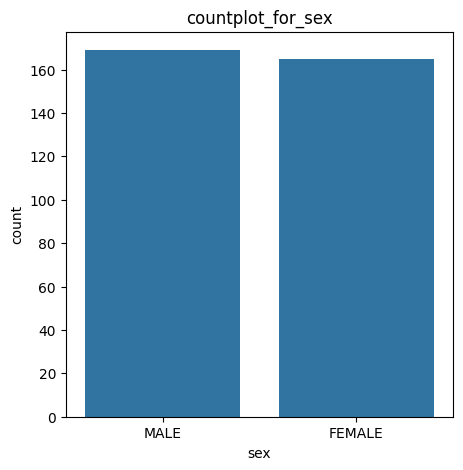

In [29]:
plt.figure(figsize=(5,5))
sns.countplot(x="sex",data=df)
plt.title("countplot_for_sex")
plt.show()

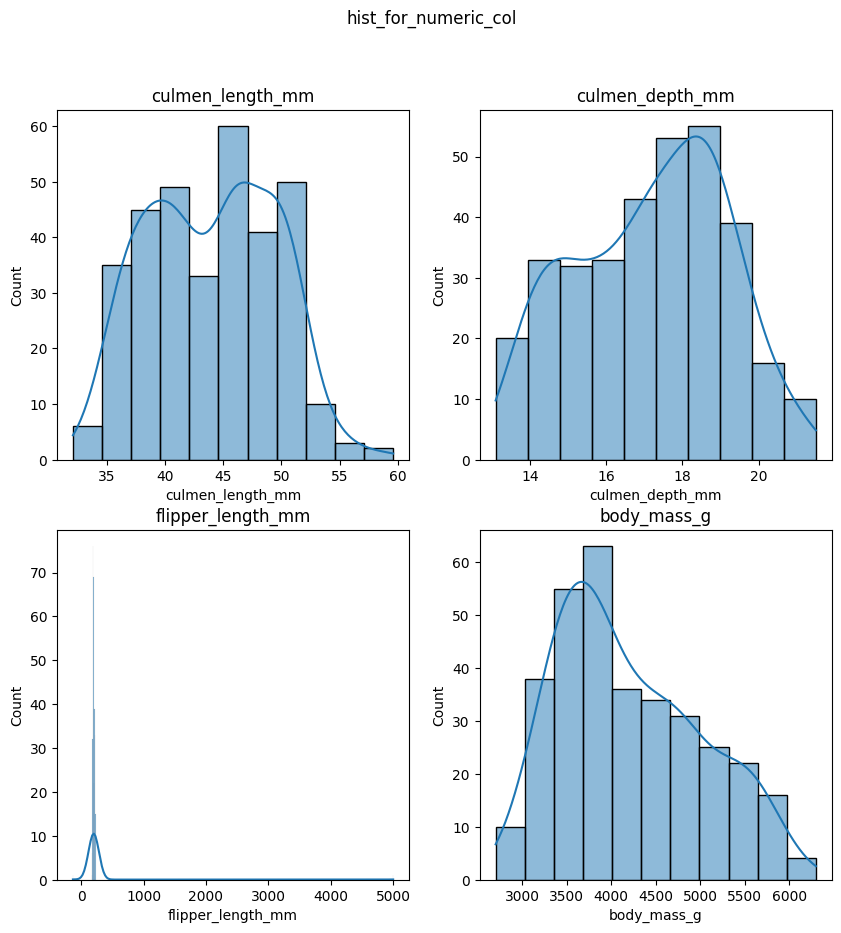

In [65]:
numeric_col = df.select_dtypes(include='number').columns
plt.figure(figsize=(10,10))
for i in range(len(numeric_col)):
    plt.subplot(2,2,i+1)
    sns.histplot(x=numeric_col[i],data=df,kde=True)
    plt.title(numeric_col[i])
    plt.suptitle("hist_for_numeric_col")
plt.show()

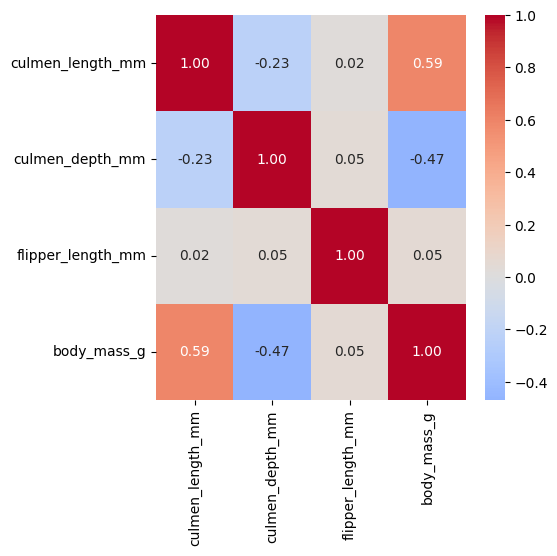

In [71]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(5,5))
sns.heatmap(corr,center=0,cmap='coolwarm',annot=True ,fmt=".2f")
plt.show()

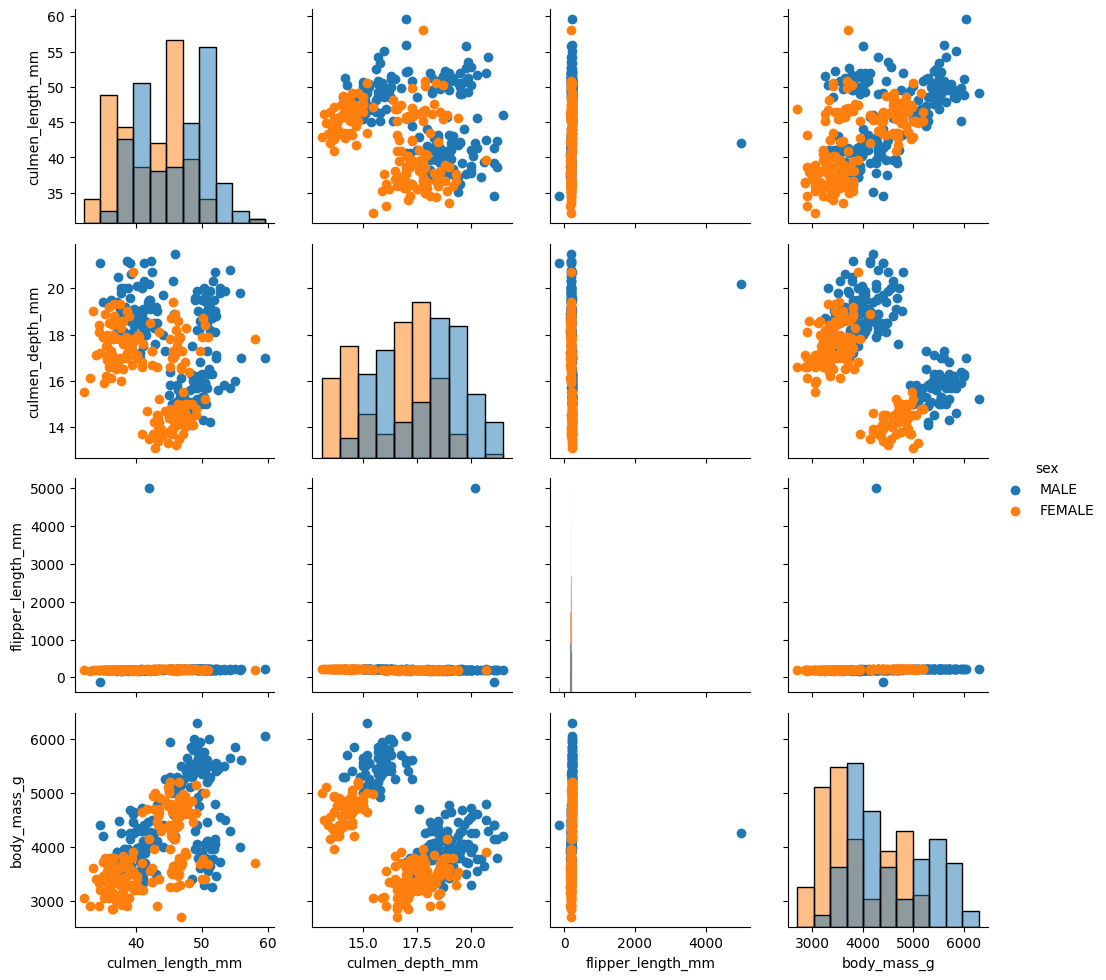

In [70]:
g = sns.PairGrid(df, hue="sex")
g.map_diag(sns.histplot)
g.map_offdiag(plt.scatter)
g.add_legend()
plt.show()

In [72]:
from sklearn.preprocessing import LabelEncoder
label_enc_sex=LabelEncoder()
df["sex"]=label_enc_sex.fit_transform(df["sex"])



In [73]:
df["sex"]

0      1
1      0
2      0
4      0
5      1
      ..
338    0
340    0
341    1
342    0
343    1
Name: sex, Length: 334, dtype: int64

In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include="number").columns.drop("sex")

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,-0.896113,0.774517,-0.126674,-0.569485,1
1,-0.822764,0.114726,-0.107681,-0.507204,0
2,-0.676065,0.419245,-0.073493,-1.192302,0
4,-1.336209,1.079036,-0.081090,-0.943175,0
5,-0.859439,1.738827,-0.092486,-0.694049,1


In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

A = []
B = []

for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)

    A.append(km.inertia_)
    B.append(silhouette_score(df, km.labels_))

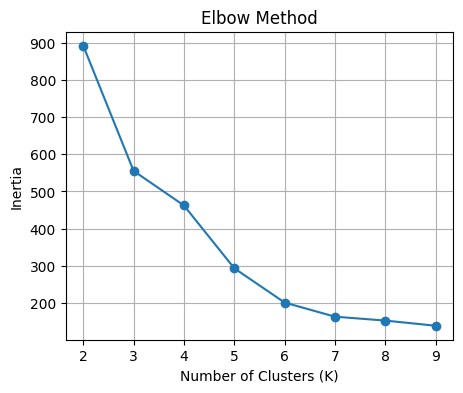

In [79]:
plt.figure(figsize=(5,4))
plt.plot(range(2,10), A, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [80]:
from sklearn.cluster import KMeans

k_final = 5

kmeans = KMeans(n_clusters=k_final, random_state=42).fit(df)

df["cluster"] = kmeans.labels_

df["cluster"].value_counts().sort_index()

cluster
0    135
1     61
2      1
3     58
4     79
Name: count, dtype: int64

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

coords_2d = pca.fit_transform(df.drop("cluster", axis=1))

explained = pca.explained_variance_ratio_

print(f"PC1 explains {explained[0]:.1%} of variance")
print(f"PC2 explains {explained[1]:.1%} of variance")
print(f"Total variance = {explained.sum():.1%}")

PC1 explains 44.4% of variance
PC2 explains 24.2% of variance
Total variance = 68.7%


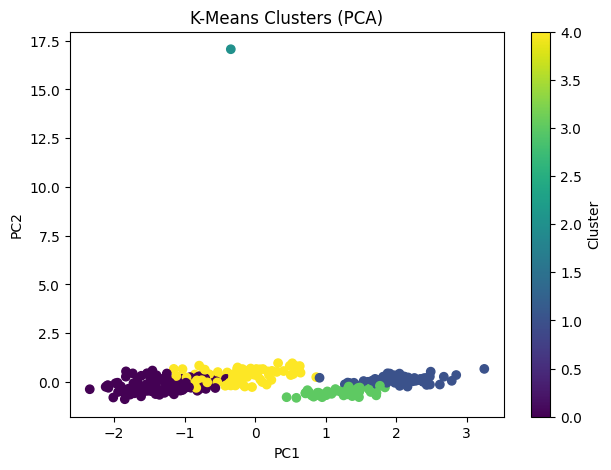

In [83]:
plt.figure(figsize=(7,5))

plt.scatter(coords_2d[:,0], coords_2d[:,1],
            c=df["cluster"], cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA)")
plt.colorbar(label="Cluster")
plt.show()

In [84]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
count,3.340000e+02,3.340000e+02,334.000000,3.340000e+02,334.000000,334.000000
mean,1.446614e-15,8.934969e-16,0.000000,-4.254747e-16,0.505988,1.655689
std,1.001500e+00,1.001500e+00,1.001500,1.001500e+00,0.500714,1.676014
min,-2.179726e+00,-2.067659e+00,-1.315642,-1.877400e+00,0.000000,0.000000
25%,-8.227640e-01,-7.988302e-01,-0.092486,-8.186120e-01,0.000000,0.000000
50%,8.493367e-02,6.397328e-02,-0.065896,-1.957956e-01,1.000000,1.000000
75%,8.413484e-01,7.745173e-01,-0.005118,6.995030e-01,1.000000,3.000000
max,2.863039e+00,2.195605e+00,18.178878,2.606878e+00,1.000000,4.000000


In [85]:
df.nlargest(5, "body_mass_g")

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,cluster
237,0.955957,-1.001843,0.025271,2.606878,1,1
253,2.863039,-0.088286,0.059459,2.295470,1,1
297,1.304366,-0.443558,0.021472,2.233188,1,1
337,0.882607,-0.494311,0.029070,2.233188,1,1
299,0.222464,-0.392805,0.032868,2.170907,1,1


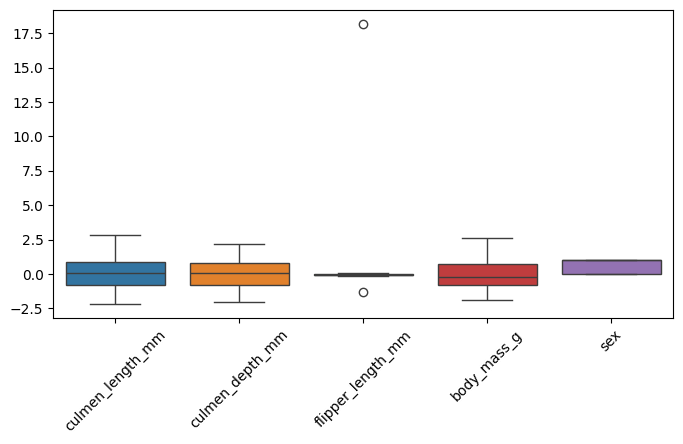

In [86]:


plt.figure(figsize=(8,4))
sns.boxplot(data=df.drop("cluster", axis=1))
plt.xticks(rotation=45)
plt.show()

In [89]:
cluster_profile = df.groupby('cluster')[numeric_col].mean().round(1)
cluster_profile['count'] = df['cluster'].value_counts().sort_index()
cluster_profile


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,count
cluster,,,,,
0,-1.0,0.5,-0.1,-0.7,135
1,1.0,-0.7,0.0,1.6,61
2,-0.4,1.5,18.2,0.1,1
3,0.3,-1.5,-0.0,0.6,58
4,0.7,0.8,-0.1,-0.4,79


In [90]:
pd.crosstab(df['cluster'], df['sex']).rename(columns={0: 'FEMALE', 1: 'MALE'})


sex,FEMALE,MALE
cluster,,
0,80,55
1,0,61
2,0,1
3,58,0
4,27,52
